## Import Libraries

In [149]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
columns = [
    "symboling","normalized-losses","make","fuel-type","aspiration",
    "num-of-doors","body-style","drive-wheels","engine-location",
    "wheel-base","length","width","height","curb-weight","engine-type",
    "num-of-cylinders","engine-size","fuel-system","bore","stroke",
    "compression-ratio","horsepower","peak-rpm","city-mpg","highway-mpg","price"
]

## Load Dataset

In [151]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Auto Price Prediction/auto_imports.csv",
                 names=columns,
                 header=None
)

df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430


In [152]:
df.shape

(201, 26)

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [154]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [155]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


## Data Cleaning

In [156]:
df.replace("?", np.nan, inplace=True)

In [157]:
#Convert to numeric (VERY IMPORTANT)
cols = [
    "normalized-losses", "bore", "stroke",
    "horsepower", "peak-rpm", "price"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [158]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845
197,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045
198,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485
199,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [160]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df["num-of-doors"] = df["num-of-doors"].fillna(
    df["num-of-doors"].mode()[0]
)

In [161]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


## Exploratory Data Analysis (EDA)

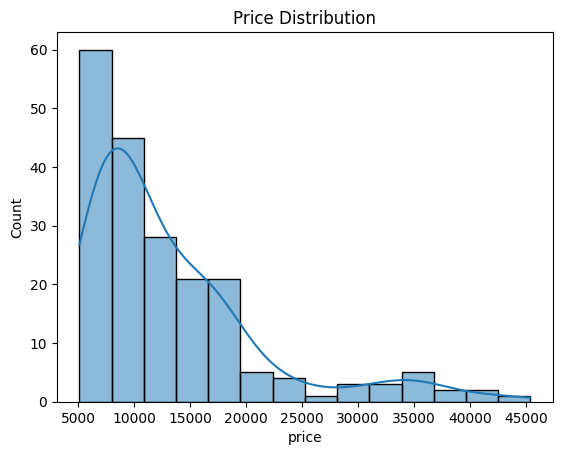

In [162]:
sns.histplot(df["price"],kde=True)
plt.title("Price Distribution")
plt.show()

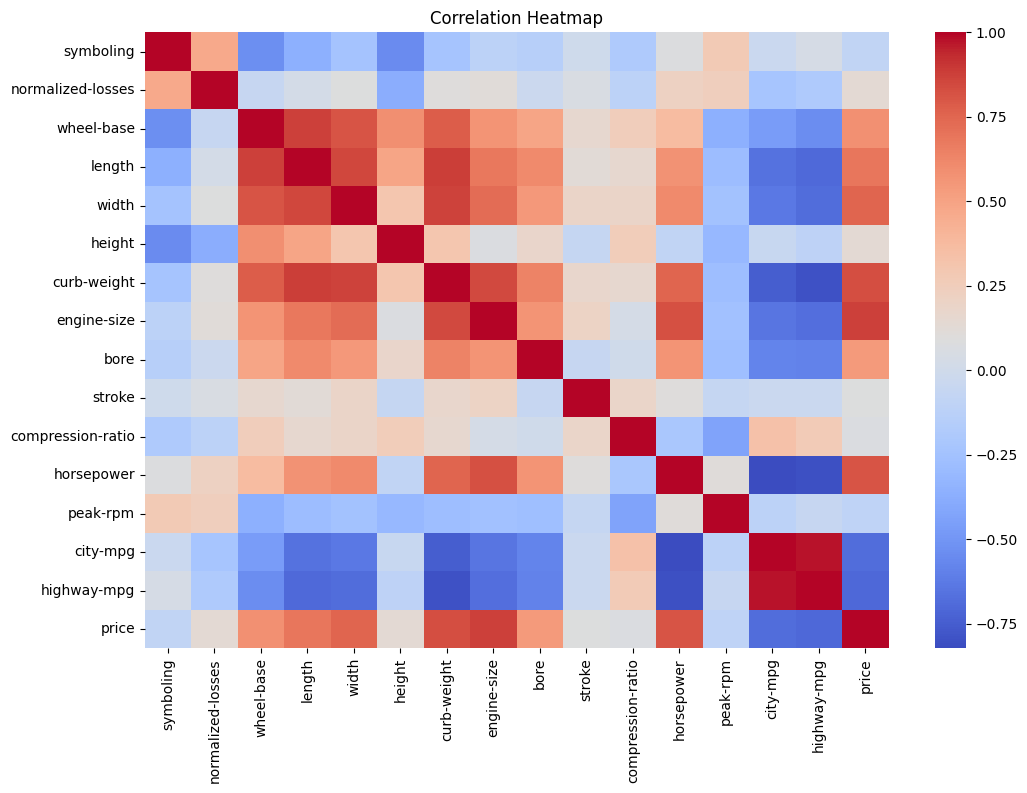

In [163]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

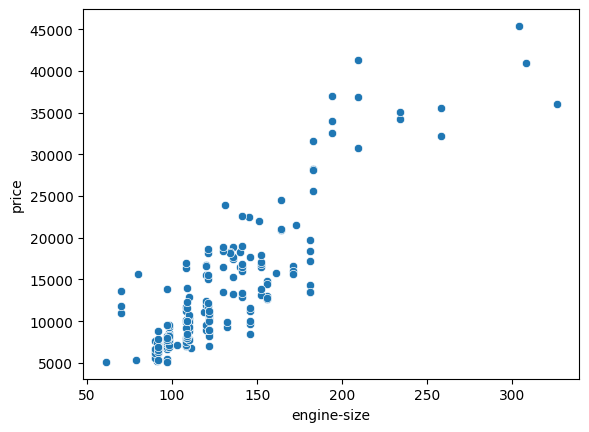

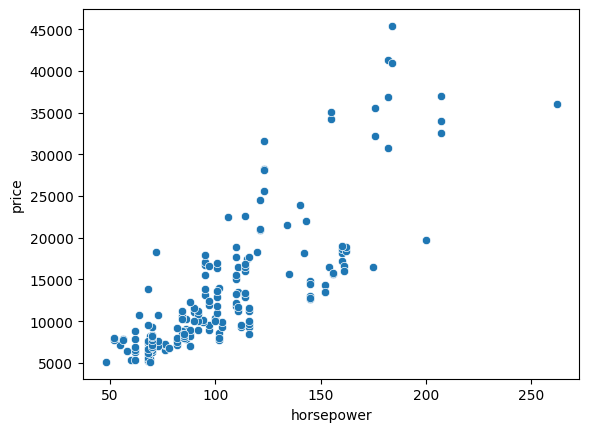

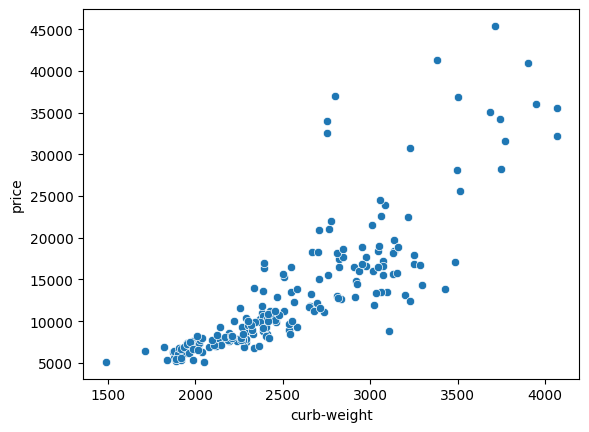

In [164]:
sns.scatterplot(x="engine-size", y="price", data=df)
plt.show()

sns.scatterplot(x="horsepower", y="price", data=df)
plt.show()

sns.scatterplot(x="curb-weight", y="price", data=df)
plt.show()

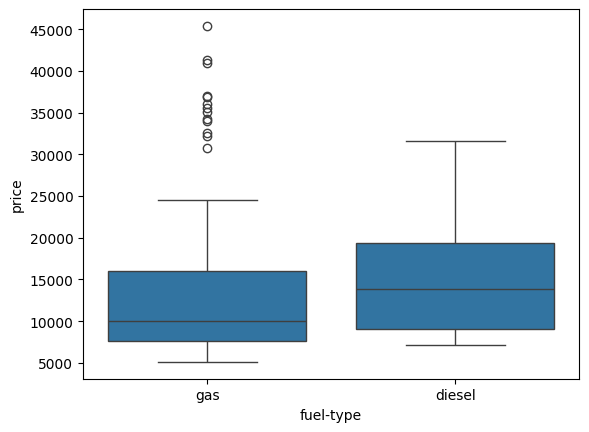

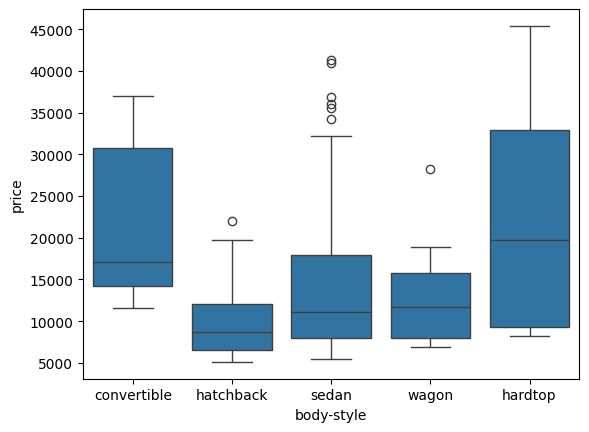

In [165]:
sns.boxplot(x="fuel-type",y="price",data=df)
plt.show()

sns.boxplot(x="body-style", y="price", data=df)
plt.show()

## Encode Categorical Variables

In [166]:
df = pd.get_dummies(df, drop_first=True)

## Split Data

In [167]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Models

Linear Regression

In [168]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Decision Tree

In [169]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [170]:
from sklearn.metrics import r2_score

print("DT R2:", r2_score(y_test, pred_dt))

DT R2: 0.9000650414134257


Random Forest

In [171]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [172]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, pred_lr)
print(r2)

0.9106870400948692


In [173]:
print("RF R2:", r2_score(y_test, pred_rf))

RF R2: 0.9261824188522011


## Model Evaluation

Three models were evaluated using R² score. Random Forest performed the best, followed by Decision Tree and Linear Regression. This shows that ensemble methods provide better performance for this dataset.

In [174]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_test, pred, name):
    print(f"--- {name} ---")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2 Score:", r2_score(y_test, pred))
    print()

evaluate(y_test, pred_lr, "Linear Regression")
evaluate(y_test, pred_dt, "Decision Tree")
evaluate(y_test, pred_rf, "Random Forest")

--- Linear Regression ---
RMSE: 3305.624364451643
R2 Score: 0.9106870400948692

--- Decision Tree ---
RMSE: 3496.67266143394
R2 Score: 0.9000650414134257

--- Random Forest ---
RMSE: 3005.219268240294
R2 Score: 0.9261824188522011



## Model Comparison

In [175]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.910687
1,Decision Tree,0.900065
2,Random Forest,0.926182


Challenges:
  Handling missing values, converting data types to numeric, and working with a small dataset were the main challenges.

## Conclusion

The objective of this project was to predict car prices using various features. After performing data cleaning and exploratory analysis, multiple machine learning models were applied. Among them, Random Forest achieved the best performance based on R² score, making it the most suitable model for this problem. Key factors influencing price include engine size, horsepower, and curb weight.